# Univariaat analyse – Minecraft Console Edition speedruns

Dit notebook voert een **univariate analyse** uit op `mce.csv`.
We bekijken steeds één variabele tegelijk (numeriek en categorisch).

## 1. Setup en eerste verkenning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid')

# Laad de dataset (zorg dat mce.csv in dezelfde map staat als dit notebook)
df = pd.read_csv('mce.csv')

print('Vorm van de data:', df.shape)
print('\nKolommen en datatypes:')
print(df.dtypes)

print('\nAantal missende waarden per kolom:')
print(df.isna().sum())

Vorm van de data: (3307, 24)

Kolommen en datatypes:
run_id                     object
player_id                  object
place                       int64
speedrun_time             float64
is_verified                  bool
verify_date                object
submitted_date             object
examiner_id                object
timing_type                object
platform_id                object
platform_name              object
platform_released_year      int64
is_level_cat                 bool
level_id                   object
level_name                 object
level_rules               float64
game_id                    object
category_id                object
cat_name                   object
cat_rules                  object
player_name                object
player_country             object
player_pronouns            object
player_signup_date         object
dtype: object

Aantal missende waarden per kolom:
run_id                       0
player_id                 3003
place              

## 2. Extra kolom: tijd in minuten
We voegen een nieuwe variabele `time_min` toe, waarbij de speedrun-tijd in seconden wordt omgezet naar minuten.

In [2]:
df['time_min'] = df['speedrun_time'] / 60

print(df[['speedrun_time', 'time_min']].head())
print('\nSamenvatting time_min (alle runs):')
print(df['time_min'].describe())

   speedrun_time  time_min
0           98.0  1.633333
1          100.0  1.666667
2          103.0  1.716667
3          103.0  1.716667
4          106.0  1.766667

Samenvatting time_min (alle runs):
count    3307.000000
mean        3.874104
std        17.128473
min         0.000017
25%         1.420342
50%         1.674983
75%         1.798717
max       672.000000
Name: time_min, dtype: float64


## 3. Univariaat – numerieke variabelen

### 3.1 `time_min` voor alle runs
We beginnen met de verdeling van `time_min` voor alle runs in de data.

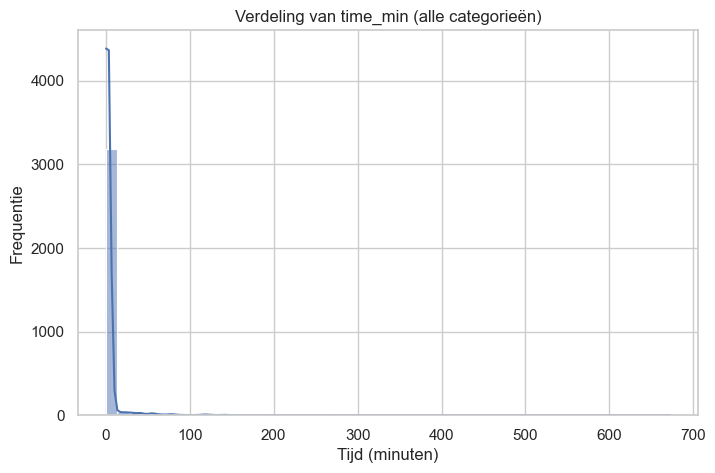

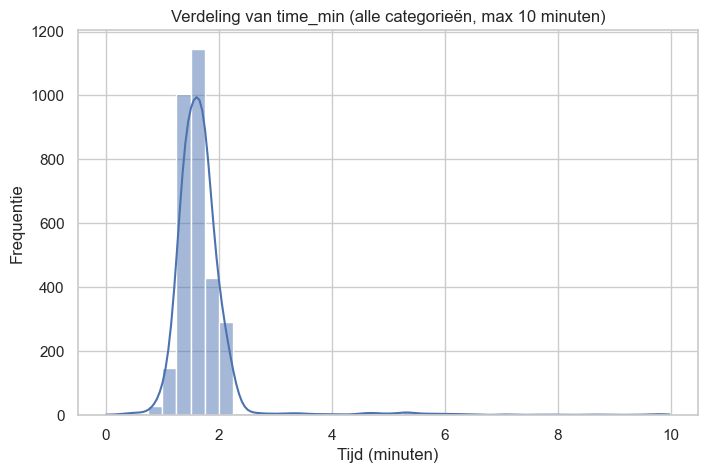

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='time_min', bins=50, kde=True)
plt.title('Verdeling van time_min (alle categorieën)')
plt.xlabel('Tijd (minuten)')
plt.ylabel('Frequentie')
plt.show()

# Inzoomen op runs tot en met 10 minuten
plt.figure(figsize=(8, 5))
sns.histplot(data=df[df['time_min'] <= 10], x='time_min', bins=40, kde=True)
plt.title('Verdeling van time_min (alle categorieën, max 10 minuten)')
plt.xlabel('Tijd (minuten)')
plt.ylabel('Frequentie')
plt.show()

### 3.2 `time_min` voor alleen *Time Attack*
Omdat `cat_name` meerdere categorieën bevat, kijken we ook naar een aparte, relatief homogene groep: **Time Attack**.

Aantal Time Attack-runs: 3001

Samenvatting time_min (Time Attack):
count    3001.000000
mean        1.621410
std         0.249605
min         0.913317
25%         1.417483
50%         1.654967
75%         1.744150
max         2.201383
Name: time_min, dtype: float64


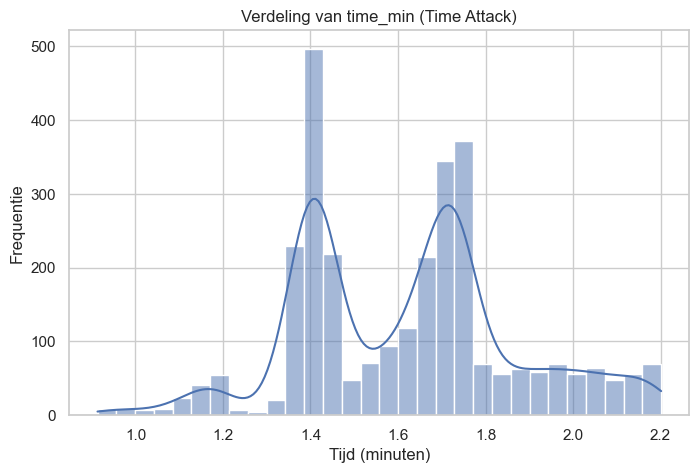

In [ ]:
df_ta = df[df['cat_name'] == 'Time Attack'].copy()

print('Aantal Time Attack-runs:', len(df_ta))
print('\nSamenvatting time_min (Time Attack):')
print(df_ta['time_min'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(data=df_ta, x='time_min', bins=30, kde=True)
plt.title('Verdeling van time_min (Time Attack)')
plt.xlabel('Tijd (minuten)')
plt.ylabel('Frequentie')
plt.show()

### 3.3 `place` (positie op de leaderboard)
We kijken ook naar de univariate verdeling van de variabele `place`.

count    3307.000000
mean      456.110674
std       307.694427
min         1.000000
25%       173.000000
50%       449.000000
75%       725.000000
max      1000.000000
Name: place, dtype: float64


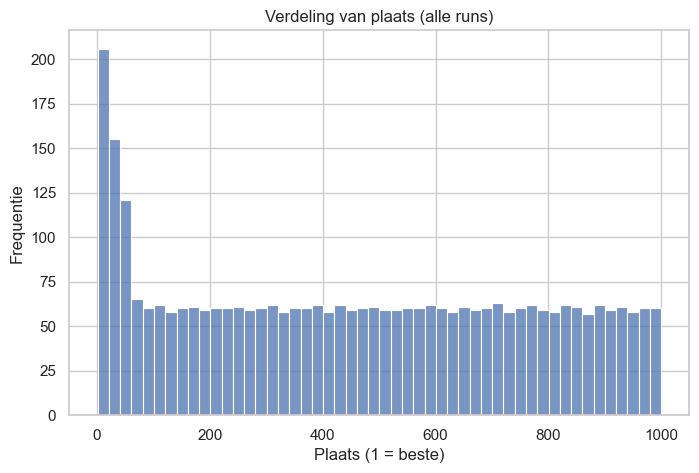


Samenvatting place (Time Attack, top 100):
count    301.000000
mean      50.308970
std       29.009439
min        1.000000
25%       25.000000
50%       50.000000
75%       75.000000
max      100.000000
Name: place, dtype: float64


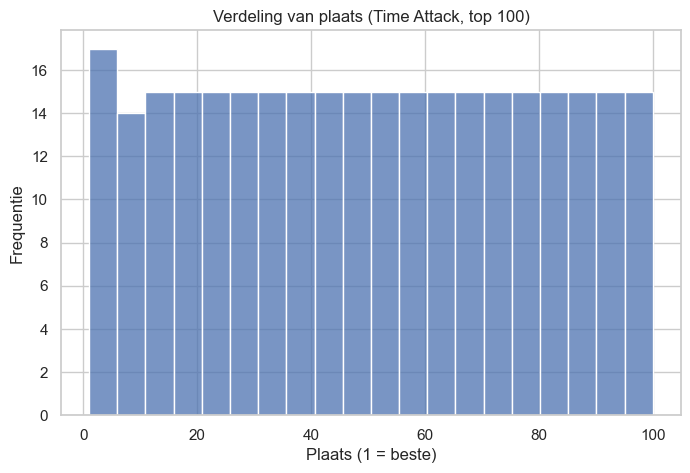

In [5]:
print(df['place'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='place', bins=50, kde=False)
plt.title('Verdeling van plaats (alle runs)')
plt.xlabel('Plaats (1 = beste)')
plt.ylabel('Frequentie')
plt.show()

# Optioneel: alleen top 100 voor Time Attack
df_ta_top100 = df_ta[df_ta['place'] <= 100].copy()
print('\nSamenvatting place (Time Attack, top 100):')
print(df_ta_top100['place'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(data=df_ta_top100, x='place', bins=20, kde=False)
plt.title('Verdeling van plaats (Time Attack, top 100)')
plt.xlabel('Plaats (1 = beste)')
plt.ylabel('Frequentie')
plt.show()

## 4. Univariaat – categorische variabelen

We bekijken nu de verdeling van verschillende categorische variabelen met behulp van countplots.

### 4.1 `cat_name` (categorie van de run)

cat_name
Time Attack                     3001
Kill Bosses                       65
Any% Tutorial World               57
Random Seed Any% Glitchless       54
Set Seed Any%                     50
Random Seed Any%                  30
Set Seed Any% Glitchless          25
Achievements                      14
Glide (Basic)                      8
Glide (100%)                       2
Kill Wither (Horse Tutorial)       1
Name: count, dtype: int64


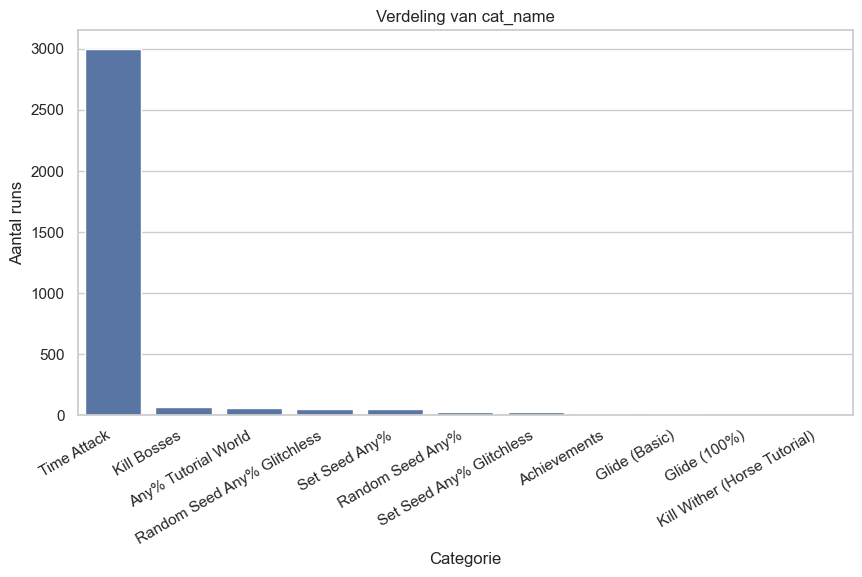

In [6]:
print(df['cat_name'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='cat_name', order=df['cat_name'].value_counts().index)
plt.title('Verdeling van cat_name')
plt.xlabel('Categorie')
plt.ylabel('Aantal runs')
plt.xticks(rotation=30, ha='right')
plt.show()

### 4.2 `platform_name` (console/platform)

platform_name
PlayStation 4       3095
Wii U                 71
PlayStation 3         44
Xbox One              37
Switch                21
Xbox 360              20
PlayStation 5         11
Xbox Series X          5
PlayStation Vita       3
Name: count, dtype: int64


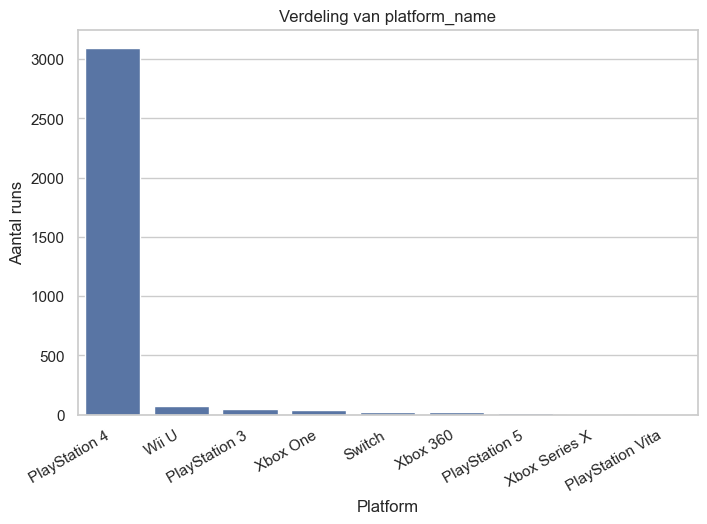

In [7]:
print(df['platform_name'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='platform_name', order=df['platform_name'].value_counts().index)
plt.title('Verdeling van platform_name')
plt.xlabel('Platform')
plt.ylabel('Aantal runs')
plt.xticks(rotation=30, ha='right')
plt.show()

### 4.3 `player_country` (land van de speler)

player_country
us    117
bh     25
ca     19
pl      8
gb      8
fr      7
it      7
gr      7
aq      7
fi      6
au      6
br      6
vh      5
sa      4
jp      4
Name: count, dtype: int64


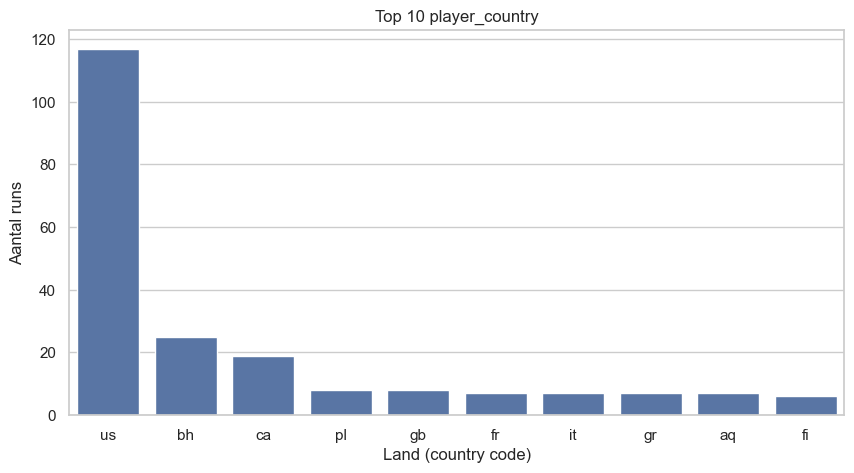

In [8]:
print(df['player_country'].value_counts().head(15))

top_countries = df['player_country'].value_counts().head(10).index

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df[df['player_country'].isin(top_countries)],
    x='player_country',
    order=top_countries
)
plt.title('Top 10 player_country')
plt.xlabel('Land (country code)')
plt.ylabel('Aantal runs')
plt.show()

### 4.4 `is_level_cat` (binaire variabele)

is_level_cat
True     3001
False     306
Name: count, dtype: int64


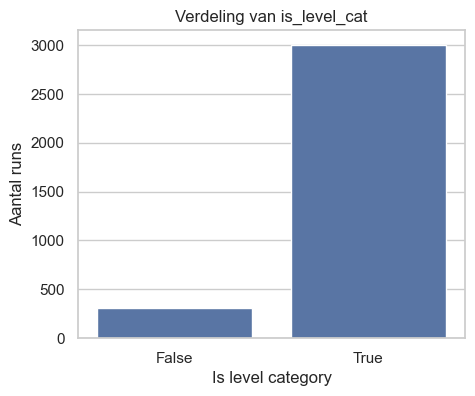

In [9]:
print(df['is_level_cat'].value_counts(dropna=False))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='is_level_cat')
plt.title('Verdeling van is_level_cat')
plt.xlabel('Is level category')
plt.ylabel('Aantal runs')
plt.show()

## 5. Korte samenvatting (interpretatie)

- **Numerieke variabelen**
  - `time_min` (alle runs) is sterk **rechts-scheef** door een aantal extreem langzame runs.
  - `time_min` binnen **Time Attack** is **unimodaal** en ongeveer **normaal verdeeld** rond ~1,6 minuut.
  - `place` over alle runs is grofweg **uniform** verdeeld over 1–1000.

- **Categorische variabelen**
  - `cat_name` is sterk **ongebalanceerd**: Time Attack domineert.
  - `platform_name` wordt gedomineerd door één platform (voornamelijk PlayStation 4).
  - `player_country` heeft veel landen, met een paar landen die duidelijk vaker voorkomen.
  - `is_level_cat` is een binaire variabele met één dominante waarde.

Deze univariate inzichten helpen later bij het kiezen van geschikte transformaties,
het maken van subsets (bijvoorbeeld alleen Time Attack) en bij het beoordelen of
categorieën voldoende waarnemingen hebben voor verdere analyses (bivariate of multivariate).